# 第9节：后门检测与防御方法

本节目标：

1) **模型行为检测**：从预测稳定性、熵分布、扰动一致性等角度发现可疑后门行为。

2) **Neural Cleanse（启发式实现）**：对每个目标类做“最小触发器”反演，比较不同类的触发器稀疏度（mask L1）是否存在异常。

3) **Fine-pruning**：剪除“在干净数据上几乎不激活”的通道/神经元，再做少量干净微调，观察 ASR 是否下降、clean acc 是否保持。

4) **净化（Purification）**：输入侧简易净化（量化/平滑/特征挤压）作为工程启发，并评估对 ASR 与 clean acc 的影响。

## 0. 路径与环境

notebooks 与 data 同级，运行目录通常为 `project_root/notebooks`。

统一使用：
```python
PROJECT_ROOT = Path.cwd().resolve().parent
```

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
TRIG_DIR = PROJECT_ROOT / 'artifacts' / 'triggers'

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR, 'exists=', DATA_DIR.exists())
print('MODELS_DIR:', MODELS_DIR, 'exists=', MODELS_DIR.exists())
print('TRIG_DIR:', TRIG_DIR, 'exists=', TRIG_DIR.exists())

device = torch.device('cpu')
print('torch:', torch.__version__, 'device:', device)


CWD: C:\Users\wingl\PycharmProjects\adversarialmeow\notebooks
PROJECT_ROOT: C:\Users\wingl\PycharmProjects\adversarialmeow
DATA_DIR: C:\Users\wingl\PycharmProjects\adversarialmeow\data exists= True
MODELS_DIR: C:\Users\wingl\PycharmProjects\adversarialmeow\models exists= True
TRIG_DIR: C:\Users\wingl\PycharmProjects\adversarialmeow\artifacts\triggers exists= True
torch: 2.10.0+cpu device: cpu


## 1. 数据加载（离线可复现）

优先读取：
- `data/digits.npz`（X, y）
- 或 `data/X.npy` + `data/y.npy`

没有则回退到 sklearn digits（8×8 灰度）。
输入统一归一化到 `[0,1]`。

In [2]:
def load_course_data(data_dir: Path):
    npz_path = data_dir / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path.name}'

    x_npy = data_dir / 'X.npy'
    y_npy = data_dir / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data(DATA_DIR)
print(info)
print('X:', X.shape, 'y:', y.shape, 'min/max:', float(X.min()), float(X.max()))

x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X01, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

print('train:', X_train_t.shape, y_train_t.shape)
print('test :', X_test_t.shape, y_test_t.shape)


Loaded local NPZ: digits.npz
X: (1797, 64) y: (1797,) min/max: 0.0 16.0
train: torch.Size([1347, 64]) torch.Size([1347])
test : torch.Size([450, 64]) torch.Size([450])


## 2. 加载模型与触发器（用于评估防御效果）

模型约定：
- `models/clean_model.pt`（可选；没有则自动训练一个干净基线）
- `models/suspect_static_backdoor_model.pt`
- `models/suspect_dynamic_backdoor_model.pt`

触发器约定（可选，用于评估 ASR）：
- `artifacts/triggers/static_trigger.npz`（mask + pattern）
- `artifacts/triggers/dynamic_trigger.py`（apply_dynamic_trigger）


In [30]:
class MLPFeat(nn.Module):
    """用于 fine-pruning 的简易可解释结构：提供 feature()"""
    def __init__(self, in_dim=64, hidden=128, emb_dim=64, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, emb_dim)
        self.fc3 = nn.Linear(emb_dim, num_classes)

    def feature(self, x):
        x = F.relu(self.fc1(x))
        z = F.relu(self.fc2(x))
        return z

    def forward(self, x):
        z = self.feature(x)
        return self.fc3(z)

def load_state_or_none(path: Path, model: nn.Module):
    if not path.exists():
        return None
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    return model

def accuracy(model, X, y, batch=256):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            pred = model(xb).argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(len(xb))
    return correct / max(total, 1)

def train_clean_baseline(model, X, y, epochs=10, batch=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            print(f'Epoch {ep:02d} | train={accuracy(model,X,y):.4f} | test={accuracy(model,X_test_t,y_test_t):.4f}')

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# clean
clean_path = MODELS_DIR / 'clean_model_tofinepruning.pt'
clean_model = MLPFeat().to(device)
if load_state_or_none(clean_path, clean_model) is None:
    print('No clean_model.pt found; training baseline...')
    train_clean_baseline(clean_model, X_train_t, y_train_t, epochs=10)
    torch.save(clean_model.state_dict(), clean_path)
    print('Saved:', clean_path)
else:
    print('Loaded:', clean_path)

# suspects
sus_static_path  = MODELS_DIR / 'suspect_static_backdoor_model_tofinepruning.pt'
sus_dynamic_path = MODELS_DIR / 'suspect_dynamic_backdoor_model_tofinepruning.pt'

suspect_static = MLPFeat().to(device)
if load_state_or_none(sus_static_path, suspect_static) is None:
    suspect_static = None
    print('WARNING: missing', sus_static_path)
else:
    print('Loaded:', sus_static_path)

suspect_dynamic = MLPFeat().to(device)
if load_state_or_none(sus_dynamic_path, suspect_dynamic) is None:
    suspect_dynamic = None
    print('WARNING: missing', sus_dynamic_path)
else:
    print('Loaded:', sus_dynamic_path)

print('\nClean acc:')
print('  clean_model     :', accuracy(clean_model, X_test_t, y_test_t))
if suspect_static is not None:
    print('  suspect_static  :', accuracy(suspect_static, X_test_t, y_test_t))
if suspect_dynamic is not None:
    print('  suspect_dynamic :', accuracy(suspect_dynamic, X_test_t, y_test_t))

# triggers (optional)
def load_static_trigger(trig_dir: Path):
    p = trig_dir / 'static_trigger_tofinepruning.npz'
    if not p.exists():
        return None
    arr = np.load(p)
    mask = torch.tensor(arr['mask'].astype(np.float32), device=device)
    pattern = torch.tensor(arr['pattern'].astype(np.float32), device=device)
    return mask, pattern

def apply_static_trigger(x, mask, pattern):
    # 1. 确保 mask 和 pattern 转为 Tensor 并移动到与 x 相同的设备
    if not isinstance(mask, torch.Tensor):
        mask = torch.tensor(mask, dtype=x.dtype, device=x.device)
    else:
        mask = mask.to(x.device)
        
    if not isinstance(pattern, torch.Tensor):
        pattern = torch.tensor(pattern, dtype=x.dtype, device=x.device)
    else:
        pattern = pattern.to(x.device)

    # 2. 关键修复：处理形状不匹配 (64 vs 8)
    # 如果输入 x 是扁平的 (Batch, 64)，而 mask 是 2D 的 (8, 8)，则拉平 mask
    if x.dim() == 2 and mask.dim() > 1:
        # 将 (8, 8) -> (1, 64) 以便广播
        mask = mask.reshape(1, -1)
        pattern = pattern.reshape(1, -1)

    # 3. 限制数值范围并应用触发器
    m = torch.clamp(mask, 0.0, 1.0)
    p = torch.clamp(pattern, 0.0, 1.0)
    
    return torch.clamp(x * (1 - m) + p * m, 0.0, 1.0)

mask_pattern = load_static_trigger(TRIG_DIR)

dyn = None
dyn_path = TRIG_DIR / 'dynamic_trigger_tofinepruning.py'
if dyn_path.exists():
    import importlib.util
    spec = importlib.util.spec_from_file_location('dynamic_trigger', dyn_path)
    dyn = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(dyn)

def make_bd_static(xb: torch.Tensor):
    if mask_pattern is None:
        raise RuntimeError('missing artifacts/triggers/static_trigger_tofinepruning.npz')
    mask, pattern = mask_pattern
    return apply_static_trigger(xb, mask, pattern)

def make_bd_dynamic(xb: torch.Tensor):
    if dyn is None or not hasattr(dyn, 'apply_dynamic_trigger'):
        raise RuntimeError('missing artifacts/triggers/dynamic_trigger.py or apply_dynamic_trigger')
    return torch.clamp(dyn.apply_dynamic_trigger(xb), 0.0, 1.0)

print('\nTrigger availability:')
print('  static_trigger_tofinepruning.npz :', mask_pattern is not None)
print('  dynamic_trigger_tofinepruning.py :', dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'))


Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\clean_model_tofinepruning.pt
Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\suspect_static_backdoor_model_tofinepruning.pt
Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\suspect_dynamic_backdoor_model_tofinepruning.pt

Clean acc:
  clean_model     : 0.8422222222222222
  suspect_static  : 0.9666666666666667
  suspect_dynamic : 0.9888888888888889

Trigger availability:
  static_trigger_tofinepruning.npz : True
  dynamic_trigger_tofinepruning.py : True


## 3. 模型行为检测（无需已知触发器）

本节提供两类可跑的行为线索：

1) **扰动一致性**：对输入做轻微随机扰动，正常样本预测更易变化；若存在强触发行为，预测可能异常稳定（或异常偏向某类）。

2) **STRIP 风格熵检测（启发式）**：对输入做多次随机混合，统计预测分布熵，熵异常低的样本更可疑。

这些方法不等价于“证明存在后门”，但能给出审计优先级线索。

Stability (clean_model) ...
Stability (suspect_static) ...


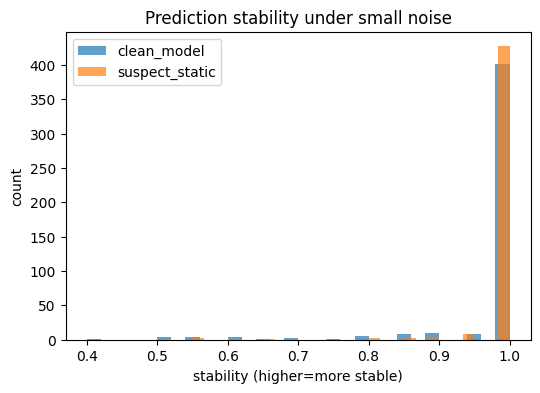

Stability (suspect_dynamic) ...


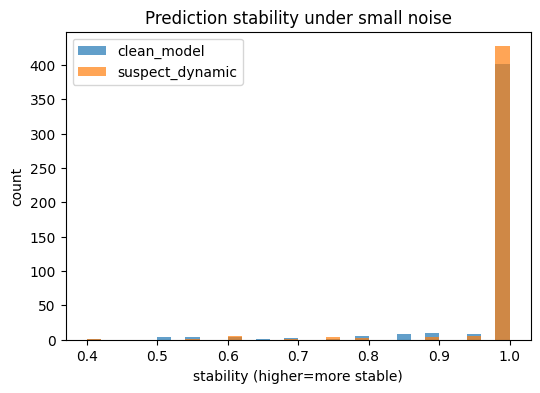

STRIP-like entropy (clean_model) ...
STRIP-like entropy (suspect_static) ...


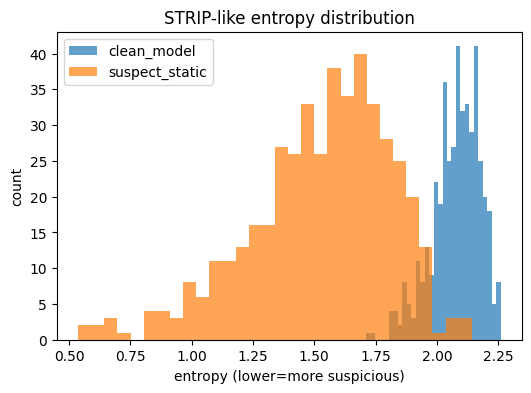

STRIP-like entropy (suspect_dynamic) ...


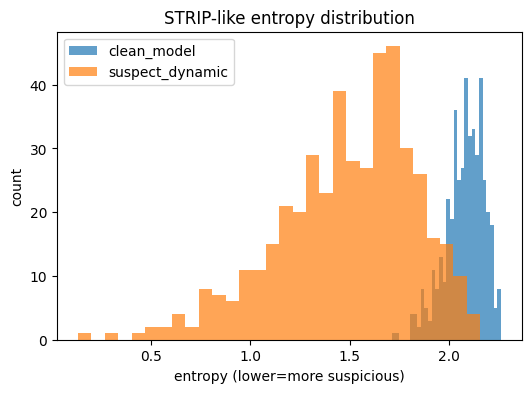

In [41]:
def add_small_noise(x: torch.Tensor, sigma=0.06):
    return torch.clamp(x + sigma*torch.randn_like(x), 0.0, 1.0)

def prediction_stability(model, X, repeats=20, sigma=0.06, batch=256):
    """返回每个样本在 repeats 次扰动下预测是否一致的比例（越高越“稳定”）。"""
    model.eval()
    all_scores = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            preds = []
            for _ in range(repeats):
                xj = add_small_noise(xb, sigma=sigma)
                preds.append(model(xj).argmax(dim=1).cpu().numpy())
            preds = np.stack(preds, axis=0)  # (repeats, B)
            mode = []
            for j in range(preds.shape[1]):
                v, c = np.unique(preds[:, j], return_counts=True)
                mode.append(c.max() / repeats)
            all_scores.append(np.array(mode, dtype=np.float32))
    return np.concatenate(all_scores)

def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

def strip_score(model, X, mix_pool, repeats=25, alpha=0.5, batch=128):
    model.eval()
    rng = np.random.default_rng(0)
    mix_pool = mix_pool.detach()
    scores = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            B = len(xb)
            ps = []
            for _ in range(repeats):
                idx = rng.choice(len(mix_pool), size=B, replace=False)
                xm = mix_pool[idx]
                xmix = torch.clamp(alpha*xb + (1-alpha)*xm, 0.0, 1.0)
                prob = F.softmax(model(xmix), dim=1).cpu().numpy()
                ps.append(prob)
            p_mean = np.mean(ps, axis=0)
            scores.append(entropy(p_mean))
    return np.concatenate(scores)

def plot_hist(a, b, title, lab_a='A', lab_b='B', xlabel='score'):
    plt.figure(figsize=(6,4))
    plt.hist(a, bins=30, alpha=0.7, label=lab_a)
    plt.hist(b, bins=30, alpha=0.7, label=lab_b)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('count')
    plt.legend()
    plt.show()

# 子集以便课堂 CPU 更快
Xs = X_test_t[:500]
pool = X_train_t[:900]

print('Stability (clean_model) ...')
st_clean = prediction_stability(clean_model, Xs)

if suspect_static is not None:
    print('Stability (suspect_static) ...')
    st_s = prediction_stability(suspect_static, Xs)
    plot_hist(st_clean, st_s, 'Prediction stability under small noise', 'clean_model', 'suspect_static', 'stability (higher=more stable)')

if suspect_dynamic is not None:
    print('Stability (suspect_dynamic) ...')
    st_d = prediction_stability(suspect_dynamic, Xs)
    plot_hist(st_clean, st_d, 'Prediction stability under small noise', 'clean_model', 'suspect_dynamic', 'stability (higher=more stable)')

print('STRIP-like entropy (clean_model) ...')
ent_clean = strip_score(clean_model, Xs, pool)

if suspect_static is not None:
    print('STRIP-like entropy (suspect_static) ...')
    ent_s = strip_score(suspect_static, Xs, pool)
    plot_hist(ent_clean, ent_s, 'STRIP-like entropy distribution', 'clean_model', 'suspect_static', 'entropy (lower=more suspicious)')

if suspect_dynamic is not None:
    print('STRIP-like entropy (suspect_dynamic) ...')
    ent_d = strip_score(suspect_dynamic, Xs, pool)
    plot_hist(ent_clean, ent_d, 'STRIP-like entropy distribution', 'clean_model', 'suspect_dynamic', 'entropy (lower=more suspicious)')


# 4. Neural Cleanse（启发式实现：反演“最小触发器”并做类间异常对比）

直觉：
- 对每个目标类 $t$，寻找一个触发器（mask + pattern），让很多输入被诱导为 $t$。
- 若某个目标类只需要“非常稀疏/非常小”的 mask 就能实现稳定诱导，可能意味着该类存在后门关联。

输出：
- 每个目标类的 mask L1 范数（越小越可疑）
- 简易异常分数（以中位数/MAD 为基准）

> 课堂实现为启发式 CPU 版，规模较小，用于理解流程与结果解读。

In [32]:
def neural_cleanse_optimize(model, X_sample, target, steps=250, lr=0.1, lam=0.02, init_mask=0.1):
    """对固定 target 类，优化 mask/pattern，使 X_sample 被诱导到 target。
    返回：mask (0..1), pattern(0..1), mask_l1
    
    注意：这是启发式实现，仅用于模型审计教学演示。
    """
    model.eval()
    B, D = X_sample.shape

    # 以 unconstrained 参数优化，再用 sigmoid 映射到 (0,1)
    m_logits = torch.full((1, D), float(np.log(init_mask/(1-init_mask))), device=device, requires_grad=True)
    p_logits = torch.zeros((1, D), device=device, requires_grad=True)

    opt = torch.optim.Adam([m_logits, p_logits], lr=lr)
    y_t = torch.full((B,), int(target), device=device, dtype=torch.long)

    for _ in range(steps):
        m = torch.sigmoid(m_logits)
        p = torch.sigmoid(p_logits)
        x_bd = torch.clamp(X_sample*(1-m) + p*m, 0.0, 1.0)
        logits = model(x_bd)
        loss_cls = F.cross_entropy(logits, y_t)
        loss_reg = m.abs().mean()  # L1 on mask
        loss = loss_cls + lam*loss_reg
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        m = torch.sigmoid(m_logits).detach().cpu().numpy().reshape(-1)
        p = torch.sigmoid(p_logits).detach().cpu().numpy().reshape(-1)
        l1 = float(np.mean(np.abs(m)))
    return m, p, l1

def mad_anomaly(scores):
    s = np.array(scores, dtype=np.float32)
    med = np.median(s)
    mad = np.median(np.abs(s - med)) + 1e-12
    # 越小越异常 => 用 (med - s)/mad
    z = (med - s) / mad
    return z, med, mad

def run_neural_cleanse(model, name='model', n_inputs=128, steps=250):
    if model is None:
        print('skip:', name)
        return None
    Xs = X_train_t[:n_inputs]
    mask_l1s = []
    masks = []
    for t in range(10):
        m, p, l1 = neural_cleanse_optimize(model, Xs, target=t, steps=steps)
        mask_l1s.append(l1)
        masks.append(m)
        print(f'[{name}] target={t} | mask_l1={l1:.6f}')
    z, med, mad = mad_anomaly(mask_l1s)
    print(f'[{name}] median(mask_l1)={med:.6f} | MAD={mad:.6f}')
    return {
        'mask_l1': mask_l1s,
        'anomaly_z': z.tolist(),
        'masks': masks
    }

# 为了课堂速度，steps 可调小（例如 120）
res_clean = run_neural_cleanse(clean_model, name='clean_model', n_inputs=128, steps=180)
res_s    = run_neural_cleanse(suspect_static, name='suspect_static', n_inputs=128, steps=180)
res_d    = run_neural_cleanse(suspect_dynamic, name='suspect_dynamic', n_inputs=128, steps=180)


[clean_model] target=0 | mask_l1=0.696789
[clean_model] target=1 | mask_l1=0.736305
[clean_model] target=2 | mask_l1=0.641782
[clean_model] target=3 | mask_l1=0.695684
[clean_model] target=4 | mask_l1=0.661687
[clean_model] target=5 | mask_l1=0.656500
[clean_model] target=6 | mask_l1=0.693326
[clean_model] target=7 | mask_l1=0.752719
[clean_model] target=8 | mask_l1=0.777664
[clean_model] target=9 | mask_l1=0.702031
[clean_model] median(mask_l1)=0.696237 | MAD=0.037144
[suspect_static] target=0 | mask_l1=0.443363
[suspect_static] target=1 | mask_l1=0.515610
[suspect_static] target=2 | mask_l1=0.414490
[suspect_static] target=3 | mask_l1=0.455227
[suspect_static] target=4 | mask_l1=0.493926
[suspect_static] target=5 | mask_l1=0.457061
[suspect_static] target=6 | mask_l1=0.479508
[suspect_static] target=7 | mask_l1=0.533875
[suspect_static] target=8 | mask_l1=0.449854
[suspect_static] target=9 | mask_l1=0.519136
[suspect_static] median(mask_l1)=0.468285 | MAD=0.025282
[suspect_dynamic] t

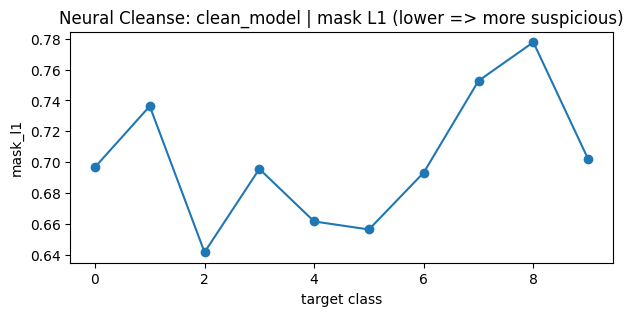

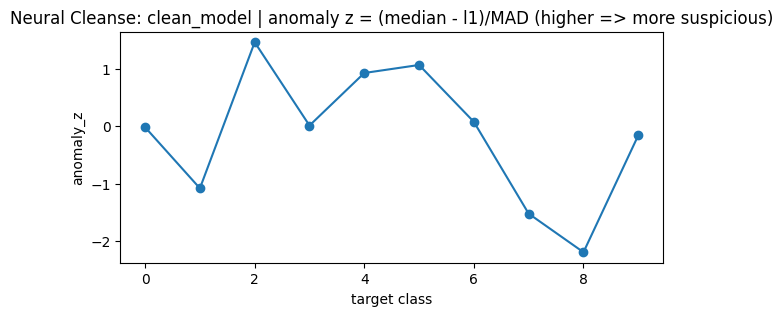

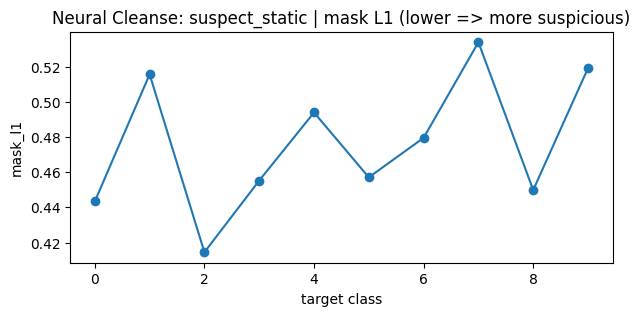

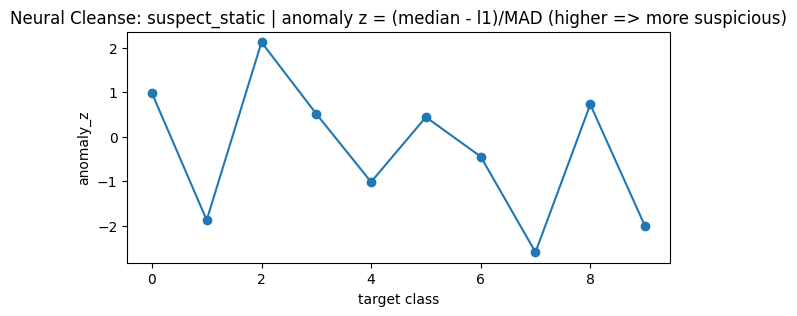

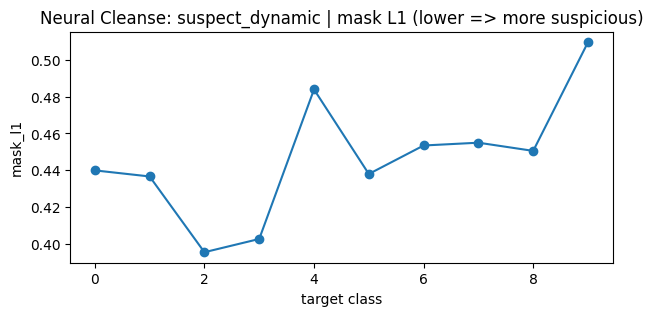

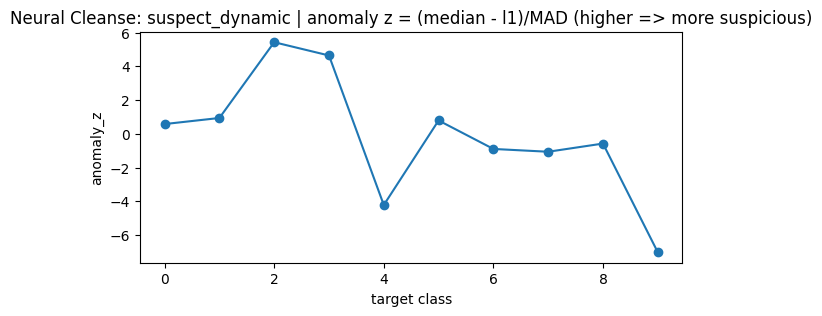

In [33]:
def plot_nc(res, title):
    if res is None:
        return
    l1 = np.array(res['mask_l1'], dtype=np.float32)
    z = np.array(res['anomaly_z'], dtype=np.float32)
    plt.figure(figsize=(7,3))
    plt.plot(l1, marker='o')
    plt.title(title + ' | mask L1 (lower => more suspicious)')
    plt.xlabel('target class')
    plt.ylabel('mask_l1')
    plt.show()

    plt.figure(figsize=(7,3))
    plt.plot(z, marker='o')
    plt.title(title + ' | anomaly z = (median - l1)/MAD (higher => more suspicious)')
    plt.xlabel('target class')
    plt.ylabel('anomaly_z')
    plt.show()

plot_nc(res_clean, 'Neural Cleanse: clean_model')
plot_nc(res_s, 'Neural Cleanse: suspect_static')
plot_nc(res_d, 'Neural Cleanse: suspect_dynamic')


### 4.1 可视化某个目标类的反演 mask（仅用于解释）

选择 anomaly_z 最大的目标类，展示对应 mask 在 8×8 上的热力图。

> 这里不导出“可复用触发器工件”，只做课堂解释。

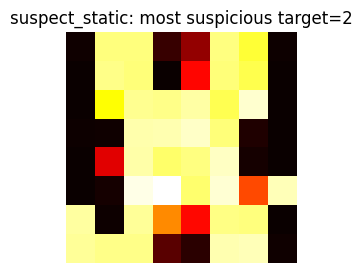

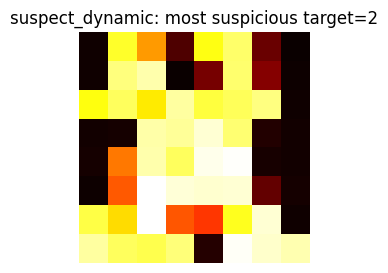

In [34]:
def show_mask_heatmap(res, title):
    if res is None:
        return
    z = np.array(res['anomaly_z'], dtype=np.float32)
    t = int(np.argmax(z))
    m = np.array(res['masks'][t], dtype=np.float32)
    plt.figure(figsize=(3,3))
    plt.imshow(m.reshape(8,8), cmap='hot')
    plt.title(f'{title}: most suspicious target={t}')
    plt.axis('off')
    plt.show()

show_mask_heatmap(res_s, 'suspect_static')
show_mask_heatmap(res_d, 'suspect_dynamic')


## 5. Fine-pruning：剪枝 + 干净微调

核心步骤：
1) 在干净训练集上统计 embedding 通道的平均激活强度
2) 剪掉“几乎不激活”的一部分通道（可能承载后门）
3) 用干净训练集少量微调

评估：
- clean acc
- （若触发器可用）ASR


In [37]:
def get_mean_activation(model: MLPFeat, X, batch=256):
    model.eval()
    sums = None
    count = 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            z = model.feature(xb)  # (B, emb_dim)
            a = z.mean(dim=0)
            if sums is None:
                sums = a.clone()
            else:
                sums += a
            count += 1
    return (sums / max(count,1)).cpu().numpy()

def prune_by_activation(model: MLPFeat, mean_act, prune_ratio=0.2):
    # mean_act: (emb_dim,)
    emb_dim = mean_act.shape[0]
    k_prune = int(emb_dim * prune_ratio)
    idx = np.argsort(mean_act)  # small -> large
    prune_idx = idx[:k_prune]
    keep_mask = torch.ones((emb_dim,), device=device)
    keep_mask[torch.tensor(prune_idx, device=device)] = 0.0
    with torch.no_grad():
        # 将被剪通道在 fc3 权重上置零（简化示例）
        model.fc3.weight.mul_(keep_mask.view(1, -1))
    return model, prune_idx

def finetune(model, X, y, epochs=3, lr=1e-3, batch=256):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        print(f'Finetune epoch {ep} done.')

def eval_asr(model, X, y, make_bd, target_class=0, batch=256):
    model.eval()
    total = 0
    hit_target = 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            xbd = make_bd(xb)
            pred = model(xbd).argmax(dim=1)
            total += int(len(xb))
            hit_target += int((pred == target_class).sum().item())
    return hit_target / max(total,1)

target_class = 0

def fine_prune_pipeline(model, name, prune_ratio=0.2, ft_epochs=3):
    if model is None:
        print('skip:', name)
        return None
    base_clean = accuracy(model, X_test_t, y_test_t)
    print(f'[{name}] before | clean acc={base_clean:.4f}')

    # 评估 ASR（可选）
    asr_static = None
    asr_dynamic = None
    if mask_pattern is not None:
        asr_static = eval_asr(model, X_test_t, y_test_t, make_bd_static, target_class=target_class)
        print(f'[{name}] before | ASR(static,target={target_class})={asr_static:.4f}')
    if dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'):
        asr_dynamic = eval_asr(model, X_test_t, y_test_t, make_bd_dynamic, target_class=target_class)
        print(f'[{name}] before | ASR(dynamic,target={target_class})={asr_dynamic:.4f}')

    # prune
    pruned = MLPFeat().to(device)
    pruned.load_state_dict(model.state_dict())
    mean_act = get_mean_activation(pruned, X_train_t)
    pruned, pruned_idx = prune_by_activation(pruned, mean_act, prune_ratio=prune_ratio)

    # finetune
    finetune(pruned, X_train_t, y_train_t, epochs=ft_epochs)

    after_clean = accuracy(pruned, X_test_t, y_test_t)
    print(f'[{name}] after  | clean acc={after_clean:.4f} | pruned={len(pruned_idx)}')

    if mask_pattern is not None:
        asr_static2 = eval_asr(pruned, X_test_t, y_test_t, make_bd_static, target_class=target_class)
        print(f'[{name}] after  | ASR(static,target={target_class})={asr_static2:.4f}')
    if dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'):
        asr_dynamic2 = eval_asr(pruned, X_test_t, y_test_t, make_bd_dynamic, target_class=target_class)
        print(f'[{name}] after  | ASR(dynamic,target={target_class})={asr_dynamic2:.4f}')

    return pruned

pruned_static = fine_prune_pipeline(suspect_static, 'suspect_static', prune_ratio=0.2, ft_epochs=30)
print('')
pruned_dynamic = fine_prune_pipeline(suspect_dynamic, 'suspect_dynamic', prune_ratio=0.2, ft_epochs=30)


[suspect_static] before | clean acc=0.9667
[suspect_static] before | ASR(static,target=0)=0.9867
[suspect_static] before | ASR(dynamic,target=0)=0.0067
Finetune epoch 1 done.
Finetune epoch 2 done.
Finetune epoch 3 done.
Finetune epoch 4 done.
Finetune epoch 5 done.
Finetune epoch 6 done.
Finetune epoch 7 done.
Finetune epoch 8 done.
Finetune epoch 9 done.
Finetune epoch 10 done.
Finetune epoch 11 done.
Finetune epoch 12 done.
Finetune epoch 13 done.
Finetune epoch 14 done.
Finetune epoch 15 done.
Finetune epoch 16 done.
Finetune epoch 17 done.
Finetune epoch 18 done.
Finetune epoch 19 done.
Finetune epoch 20 done.
Finetune epoch 21 done.
Finetune epoch 22 done.
Finetune epoch 23 done.
Finetune epoch 24 done.
Finetune epoch 25 done.
Finetune epoch 26 done.
Finetune epoch 27 done.
Finetune epoch 28 done.
Finetune epoch 29 done.
Finetune epoch 30 done.
[suspect_static] after  | clean acc=0.9711 | pruned=12
[suspect_static] after  | ASR(static,target=0)=0.6844
[suspect_static] after  | AS

## 6. 净化（Purification）：输入侧简易防御

这里给出三种轻量净化（CPU 可跑）：

1) **特征挤压 / 量化（Feature Squeezing）**：将像素值量化到更少级别，压制细微触发图案。

2) **平滑（Smoothing）**：对 8×8 做简单均值滤波（演示版）。

3) **组合净化**：先量化再平滑。

评估：
- clean acc
- （若触发器可用）ASR


In [36]:
def squeeze_quantize(x: torch.Tensor, levels=8):
    # x in [0,1]
    return torch.round(x * (levels-1)) / (levels-1)

def smooth_mean_3x3(x: torch.Tensor):
    # x: (B, 64) -> (B, 1, 8, 8)
    B = x.shape[0]
    img = x.view(B, 1, 8, 8)
    # padding=1 mean filter
    kernel = torch.ones((1,1,3,3), device=x.device) / 9.0
    img2 = F.conv2d(img, kernel, padding=1)
    return torch.clamp(img2.view(B, 64), 0.0, 1.0)

def purify(x: torch.Tensor, levels=8, do_smooth=True):
    y = squeeze_quantize(x, levels=levels)
    if do_smooth:
        y = smooth_mean_3x3(y)
    return y

def eval_under_purification(model, name, levels=8, do_smooth=True, target_class=0):
    if model is None:
        print('skip:', name)
        return
    model.eval()
    # clean
    with torch.no_grad():
        Xp = purify(X_test_t, levels=levels, do_smooth=do_smooth)
    clean_acc = accuracy(model, Xp, y_test_t)
    print(f'[{name}] purified clean acc={clean_acc:.4f} (levels={levels}, smooth={do_smooth})')

    if mask_pattern is not None:
        def bd_then_purify(xb):
            return purify(make_bd_static(xb), levels=levels, do_smooth=do_smooth)
        asr = eval_asr(model, X_test_t, y_test_t, bd_then_purify, target_class=target_class)
        print(f'[{name}] purified ASR(static,target={target_class})={asr:.4f}')

    if dyn is not None and hasattr(dyn, 'apply_dynamic_trigger'):
        def bd_then_purify2(xb):
            return purify(make_bd_dynamic(xb), levels=levels, do_smooth=do_smooth)
        asr = eval_asr(model, X_test_t, y_test_t, bd_then_purify2, target_class=target_class)
        print(f'[{name}] purified ASR(dynamic,target={target_class})={asr:.4f}')

target_class = 0

print('== Purification eval (suspects) ==')
eval_under_purification(suspect_static, 'suspect_static', levels=8, do_smooth=True, target_class=target_class)
eval_under_purification(suspect_dynamic, 'suspect_dynamic', levels=8, do_smooth=True, target_class=target_class)
print('')
eval_under_purification(suspect_static, 'suspect_static', levels=4, do_smooth=False, target_class=target_class)
eval_under_purification(suspect_dynamic, 'suspect_dynamic', levels=4, do_smooth=False, target_class=target_class)


== Purification eval (suspects) ==
[suspect_static] purified clean acc=0.7000 (levels=8, smooth=True)
[suspect_static] purified ASR(static,target=0)=0.8644
[suspect_static] purified ASR(dynamic,target=0)=0.0000
[suspect_dynamic] purified clean acc=0.7067 (levels=8, smooth=True)
[suspect_dynamic] purified ASR(static,target=0)=0.0000
[suspect_dynamic] purified ASR(dynamic,target=0)=0.0067

[suspect_static] purified clean acc=0.9556 (levels=4, smooth=False)
[suspect_static] purified ASR(static,target=0)=0.9800
[suspect_static] purified ASR(dynamic,target=0)=0.0044
[suspect_dynamic] purified clean acc=0.9800 (levels=4, smooth=False)
[suspect_dynamic] purified ASR(static,target=0)=0.0489
[suspect_dynamic] purified ASR(dynamic,target=0)=1.0000


## 7. 本节练习


1) 模型行为检测：
- stability 分布对比（clean vs suspect）
- STRIP-like 熵分布对比（clean vs suspect）

2) Neural Cleanse：
- 每个 target 类的 mask_l1 曲线
- anomaly_z 曲线
- 最可疑 target 的 mask 热力图（解释其含义）

3) Fine-pruning：
- 剪枝+微调前后 clean acc 与 ASR（若可测）

4) Purification：
- 至少两组参数（levels/smooth）下的 clean acc 与 ASR（若可测）

5) 为什么不同防御对 clean acc 与 ASR 的影响存在 trade-off？

6) 为什么“检测结果”通常是概率性线索而非确定性证明？
